### Figure 1: Correlated gene clusters. 

* A: Number of clusters in each tissue vs the percent of all expressed genes
* B: Example cluster of HOX genes
* C: Distribution of the number of genes per cluster
* D: Distribution of positive, negative, or mixed correlations in clusters
* D: Annotation enrichments of correlated clusters 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import upsetplot as up
from tqdm.auto import tqdm 
from scipy.stats import spearmanr
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
import pyranges as pr

# set higher figure resolution
import matplotlib as mpl


tqdm.pandas()

# get outputs from a config file
prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append(f'{config["working_dir"]}/{config["code_dir"]}')
from utils import *
from annotate_clusters import * 


%config InlineBackend.figure_formats = ['png']
# %matplotlib inline
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

plt.rcParams.update({
    'font.size': 8,           # Base font size
    'axes.labelsize': 9,      # Axis labels
    'axes.titlesize': 10,     # Subplot titles
    'xtick.labelsize': 8,     # X-axis tick labels
    'ytick.labelsize': 8,     # Y-axis tick labels
    'legend.fontsize': 8,     # Legend
    'pdf.fonttype': 42,       # Embed fonts in PDF
    'ps.fonttype': 42,        # Embed fonts in PS
})

/home/klawren/.pixi/envs/python/lib/python3.12/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# colors
corr_cmap = LinearSegmentedColormap.from_list('corr', [(0, '#69AED1'), (.5, 'white'), (1, '#B83A4B')])

gtex_tissue_dict = {
    "Adipose_Subcutaneous": "#FFA54F",
    "Adipose_Visceral_Omentum": "#EE9A00",
    "Artery_Tibial": "#FF0000",
    "Cells_Cultured_fibroblasts": "#9AC0CD",
    "Esophagus_Mucosa": "#8B7355",
    "Esophagus_Muscularis": "#CDAA7D",
    "Lung": "#9ACD32",
    "Muscle_Skeletal": "#7A67EE",
    "Nerve_Tibial": "#FFD700",
    "Skin_Not_Sun_Exposed_Suprapubic": "#3A5FCD",
    "Skin_Sun_Exposed_Lower_leg": "#1E90FF",
    "Thyroid": "#008B45",
    "Whole_Blood": "#FF00FF"
}

gtex_tissue_abbrev = ['ADPSBQ',
                      'ADPVSC',
                      'ARTTBL',
                      'CELLS',
                      'ESPMCS',
                      'ESPMSL',
                      'LUNG',
                      'MSCLSK',
                      'NERVET',
                      'SKINNS',
                      'SKINS',
                      'THYROID',
                      'WHLBLD']

gtex_tissue_pal = sns.color_palette(list(gtex_tissue_dict.values()))
gtex_tissue_pal_df = pd.DataFrame(pd.Series(gtex_tissue_dict), columns=['hex']).reset_index(names=['tissue_id'])


Number of clusters in each tissue vs the percent of all expressed genes

In [3]:
# load in clusters
clusters = load_across_tissues(config, load_clusters_annotated)

# get total number of clusters and genes in clusters
cluster_counts = clusters.groupby('tissue_id').agg({'num_genes':'sum', 'cluster_id':'nunique'}).reset_index()
tissue_ids = load_tissue_ids(config)

# # get total number of expressed genes
num_expressed_genes = [len(load_expression(config, tissue_id)) for tissue_id in tissue_ids]
cluster_counts['expressed_genes'] = num_expressed_genes
cluster_counts['fraction_genes_in_cluster'] = cluster_counts['num_genes']/cluster_counts['expressed_genes']*100

Example cluster correlation

In [4]:
# Example cluster correaltion 
gencode = pd.read_table(config['gencode_path'])
gid_gencode = gencode.set_index('gene_id')

example_cluster = clusters[clusters['cluster_id']=='ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4'].iloc[0]

# gene gene ids sorted by tss start
sorted_cluster = gid_gencode.loc[example_cluster['cluster_id'].split('_')].sort_values('start')
sorted_gene_ids = sorted_cluster.index.values
# get normed expression 
expression = load_cluster_expression(config, example_cluster['tissue_id'])
expression['cluster_id'] = expression['gene_id'].str.split('_e_').str[0]
expression['egene_id'] = expression['gene_id'].str.split('_e_').str[1]
cluster_expression = expression[(expression['cluster_id']==example_cluster['cluster_id'])].set_index('egene_id').loc[sorted_gene_ids]
# get correlation of expression
sample_ids = cluster_expression.columns[cluster_expression.columns.str.contains('GTEX')]
cluster_corr, cluster_pvalue = spearmanr(cluster_expression[sample_ids], axis=1)
# make df with readable gene names
cluster_corr = pd.DataFrame(cluster_corr, index=sorted_cluster['gene_name'].values, columns=sorted_cluster['gene_name'].values)

Cluster positive vs negative correlaiton

In [5]:
clusters[['mean_pos_corr', 'mean_neg_corr']] = clusters[['mean_pos_corr', 'mean_neg_corr']].fillna(0)
clusters['positive correlation'] = clusters['mean_pos_corr'] != 0
clusters['negative correlation'] = clusters['mean_neg_corr'] != 0
clusters_upset = clusters.set_index('positive correlation').set_index('negative correlation', append=True)

Annotation erichment of clusters

In [6]:
# load clusters
annotated_clusters = load_across_tissues(config,load_clusters_annotated)
annotated_clusters['cluster_length'] = np.log10(annotated_clusters['end'].astype(int) - annotated_clusters['start'].astype(int))
annotated_clusters['mean_pos_corr'] = np.where(annotated_clusters['mean_pos_corr']==0, np.nan, annotated_clusters['mean_pos_corr'])
annotated_clusters['mean_neg_corr'] = np.where(annotated_clusters['mean_neg_corr']==0, np.nan, annotated_clusters['mean_neg_corr'])
annotated_clusters = annotated_clusters[annotated_clusters['num_genes']<6]


# load nulls
annotated_nulls = []
for tissue_id in load_tissue_ids(config):
    for num_genes in [2,3,4,5]:
        annotated_null_subset = load_null_clusters_annotated(config, tissue_id, num_genes)
        annotated_null_subset['cluster_length'] = np.log10(annotated_null_subset['end'].astype(int) - annotated_null_subset['start'].astype(int))
        annotated_null_subset['tissue_id'] = tissue_id
        annotated_nulls.append(annotated_null_subset)

annotated_null_clusters = pd.concat(annotated_nulls)

# modify overlapping to exclude promoters
def exclude_shared_promoters(cluster_df):
    has_shared_promoter = cluster_df['has_shared_same_promoter'] | cluster_df['has_shared_opp_promoter']
    cluster_df['has_opp_overlapping'] = cluster_df['has_opp_overlapping'] & ~has_shared_promoter
    cluster_df['has_same_overlapping'] = cluster_df['has_same_overlapping'] & ~has_shared_promoter
    return cluster_df

annotated_null_clusters = exclude_shared_promoters(annotated_null_clusters)
annotated_clusters = exclude_shared_promoters(annotated_clusters)


# Define annotation columns 
annotation_cols = ['has_paralog', 'has_go', 'has_same_overlapping', 'has_shared_same_promoter', 
    'has_abc', 'has_shared_opp_promoter', 'has_opp_overlapping', 'has_ctcf', 'has_tad']

# Set minimum thresholds for enrichment calculation
min_group_size = 10
min_expected_freq = 5

# Categorize clusters by correlation type
clusters_cat = categorize_correlation_type(annotated_clusters)

all_results = []

# Overall enrichment (all clusters vs null)
overall_enrichment = calculate_enrichment_with_covariates(
    annotated_clusters, annotated_null_clusters, annotation_cols, 
    min_group_size=min_group_size, min_expected_freq=min_expected_freq
)

# Add overall results
for _, row in overall_enrichment.iterrows():
    all_results.append({
        'annotation': row['annotation'],
        'corr_type': 'overall',
        'odds_ratio': row['odds_ratio'],
        'ci_lower': row['ci_lower'],
        'ci_upper': row['ci_upper'],
        'p_value': row['p_value'],
        'n_clusters': len(annotated_clusters),
        'n_null': len(annotated_null_clusters),
        'reason': row['reason']
    })

# Calculate enrichment for each correlation type vs null
corr_types = ['positive_only', 'negative_only', 'both_corr']

for corr_type in corr_types:
    clusters_subset = clusters_cat[clusters_cat['corr_type'] == corr_type]
    
    if len(clusters_subset) > 0:
        enrichment = calculate_enrichment_with_covariates(
            clusters_subset, annotated_null_clusters, annotation_cols,
            min_group_size=min_group_size, min_expected_freq=min_expected_freq
        )
        
        for _, row in enrichment.iterrows():
            all_results.append({
                'annotation': row['annotation'],
                'corr_type': corr_type,
                'odds_ratio': row['odds_ratio'],
                'ci_lower': row['ci_lower'],
                'ci_upper': row['ci_upper'],
                'p_value': row['p_value'],
                'n_clusters': len(clusters_subset),
                'n_null': len(annotated_null_clusters),
                'reason': row['reason']
            })
    else:
        # Add NA entries for this correlation type
        for annotation in annotation_cols:
            all_results.append({
                'annotation': annotation,
                'corr_type': corr_type,
                'odds_ratio': np.nan,
                'ci_lower': np.nan,
                'ci_upper': np.nan,
                'p_value': np.nan,
                'n_clusters': 0,
                'n_null': len(annotated_null_clusters),
                'reason': 'no_clusters_of_this_type'
            })

results_df = pd.DataFrame(all_results)

Low expected frequency for has_shared_same_promoter: min_expected=4.46
Low expected frequency for has_same_overlapping: min_expected=0.87
Low expected frequency for has_shared_same_promoter: min_expected=0.60
Low expected frequency for has_opp_overlapping: min_expected=4.36


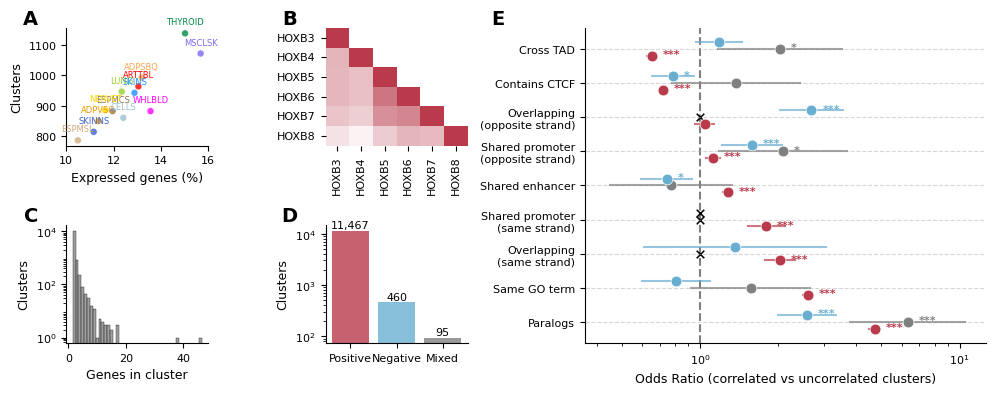

In [19]:
# Create the multi-panel figure
fig = plt.figure(figsize=(10, 4))

# Panel A: Number of clusters in each tissue vs the percent of all expressed genes
# Top left (1/2 height, 1/6 width)
ax_a = plt.subplot2grid((2, 4), (0, 0), rowspan=1, colspan=1)

sns.scatterplot(cluster_counts, x='fraction_genes_in_cluster', y='cluster_id', 
                hue='tissue_id', palette=gtex_tissue_pal, ax=ax_a, s=25, alpha=.8, legend=False)

# Add tissue labels to each point with better positioning to avoid overlap
for idx, row in cluster_counts.iterrows():
    tissue_id = row['tissue_id']
    color = gtex_tissue_dict[tissue_id]
    # Get the abbreviated tissue name
    tissue_abbrev = gtex_tissue_abbrev[list(gtex_tissue_dict.keys()).index(tissue_id)]
    
    # Position labels centered above the points
    ax_a.annotate(tissue_abbrev, 
                  xy=(row['fraction_genes_in_cluster'], row['cluster_id']),
                  xytext=(0, 5), textcoords='offset points',
                  fontsize=6, color=color, ha='center', va='bottom')

ax_a.set_ylabel('Clusters')
ax_a.set_xlabel('Expressed genes (%)')
ax_a.set_xticks([10, 12, 14, 16])

ax_a.spines[['top', 'right']].set_visible(False)
# Add panel label A in the top left corner
ax_a.text(-.2,1, 'A', transform=ax_a.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

# Panel C: Distribution of the number of genes per cluster (now in bottom left)
# Bottom left (1/2 height, 1/6 width) - SWAPPED with B
ax_c = plt.subplot2grid((2, 4), (1, 0), rowspan=1, colspan=1)

sns.histplot(clusters, x='num_genes', ax=ax_c, color='grey', discrete=True)
ax_c.spines[['top', 'right']].set_visible(False)
ax_c.set_yscale('log')
ax_c.set_ylabel('Clusters')
ax_c.set_xlabel('Genes in cluster')
ax_c.set_yticks([1, 100, 10000])
# Add panel label C in the top left corner (keeping C label)
ax_c.text(-.2,1, 'C', transform=ax_c.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

# Panel B: HOXB expression correlation heatmap (now in top middle)
# Top middle (1/2 height, 1/6 width) - SWAPPED with C
ax_b = plt.subplot2grid((2, 4), (0, 1), rowspan=1, colspan=1)

# Create the heatmap using existing cluster_corr
sns.heatmap(cluster_corr, mask=np.triu(np.ones_like(cluster_corr), k=1),
            cmap=corr_cmap, vmin=-1, vmax=1, ax=ax_b, 
            cbar_kws={'label':'Spearman Correlation', 'shrink': 0.6, 'aspect': 10}, 
            xticklabels=True, yticklabels=True, cbar=False)
# cbar = ax_b.collections[-1].colorbar
# cbar.ax.tick_params(labelsize=6)  # Make tick labels smaller
# cbar.ax.set_ylabel('Spearman Correlation', fontsize=7)  # Make axis label smaller
ax_b.tick_params("y", rotation=0)
# Add panel label B in the top left corner (keeping B label)
ax_b.text(-.2,1, 'B', transform=ax_b.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

# Panel D: Counts of correlation types (positive only, negative only, mixed)
# Bottom middle (1/2 height, 1/6 width)
ax_d = plt.subplot2grid((2, 4), (1, 1), rowspan=1, colspan=1)

# Create correlation type categories using existing columns
clusters['corr_type'] = np.where(
    (clusters['positive correlation']) & (~clusters['negative correlation']), 'positive_only',
    np.where((~clusters['positive correlation']) & (clusters['negative correlation']), 'negative_only', 'mixed')
)

# Count each type
corr_counts = clusters['corr_type'].value_counts()

# Create bar plot
colors = ['#B83A4B', '#69AED1', 'grey']
bars = ax_d.bar(range(len(corr_counts)), corr_counts.values, color=colors, alpha=0.8)

# Customize panel D
ax_d.set_ylabel('Clusters')
ax_d.set_xticks(range(len(corr_counts)))
ax_d.set_xticklabels(['Positive', 'Negative', 'Mixed'])
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)
ax_d.set_yscale('log')
# Add panel label D in the top left corner
ax_d.text(-.2, 1, 'D', transform=ax_d.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

# Add value labels on bars
for bar, count in zip(bars, corr_counts.values):
    height = bar.get_height()
    ax_d.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
               f'{count:,}', ha='center', va='bottom', fontsize=8)

# Panel E: Enrichment of correlated clusters (enrichment part)
# Full height, 2/6 width (far right) - aligned with A and B (now)
ax_e = plt.subplot2grid((2, 4), (0, 2), rowspan=2, colspan=2)
# Define colors for each correlation type
colors = {
    'positive_only': '#B83A4B',
    'both_corr': 'grey',
    'negative_only': '#69AED1'
}

# Filter out overall and only use successful results for plotting
plot_data = results_df[(results_df['corr_type'] != 'overall') & (results_df['reason'] == 'success')]
skipped_data = results_df[(results_df['corr_type'] != 'overall') & (results_df['reason'] != 'success')]

# Define y-positions for each annotation
y_positions = {annotation: i for i, annotation in enumerate(annotation_cols)}

# Plot successful enrichment results
for corr_type in ['positive_only', 'both_corr', 'negative_only']:
    subset = plot_data[plot_data['corr_type'] == corr_type]
    
    if len(subset) == 0:
        continue
        
    # Offset y positions slightly for different correlation types
    offset = (list(colors.keys()).index(corr_type) - 1) * 0.2
    y_vals = [y_positions[ann] + offset for ann in subset['annotation']]
    
    # Plot odds ratios
    ax_e.scatter(subset['odds_ratio'], y_vals, 
              color=colors[corr_type], s=60,
              zorder=3, edgecolors='white', linewidth=0.5)
    
    # Plot confidence intervals
    for idx, (_, row) in enumerate(subset.iterrows()):
        y_val = y_vals[idx]
        ax_e.plot([row['ci_lower'], row['ci_upper']], [y_val, y_val], 
               color=colors[corr_type], alpha=0.7, linewidth=1.5, zorder=2)
        
        # Add significance markers
        if pd.notna(row['p_value']):
            if row['p_value'] < 0.001:
                marker = '***'
            elif row['p_value'] < 0.01:
                marker = '**'
            elif row['p_value'] < 0.05:
                marker = '*'
            else:
                marker = ''
            
            if marker:
                ax_e.text(row['odds_ratio'] * 1.1, y_val+.05, marker, 
                       va='center', color=colors[corr_type], fontweight='bold', zorder=4)

# Plot skipped calculations as gray X marks
for corr_type in ['positive_only', 'both_corr', 'negative_only']:
    subset_skipped = skipped_data[skipped_data['corr_type'] == corr_type]
    
    if len(subset_skipped) == 0:
        continue
        
    # Use same offset as successful results
    offset = (list(colors.keys()).index(corr_type) - 1) * 0.2
    y_vals_skipped = [y_positions[ann] + offset for ann in subset_skipped['annotation']]
    
    # Plot X marks for skipped calculations at x=1 (no enrichment line)
    ax_e.scatter([1] * len(y_vals_skipped), y_vals_skipped, 
              marker='x', color='k', s=30,
              zorder=1, linewidth=1.1)

# Create custom legend elements
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='x', color='k', linestyle='None', markersize=8, 
           label='Skipped\n(insufficient expected frequency)')
]

# Customize panel E
ax_e.axvline(x=1, color='black', linestyle='--', alpha=0.5, zorder=1)
ax_e.set_xlabel('Odds Ratio (correlated vs uncorrelated clusters)')

# Set y-axis
ax_e.set_yticks(range(len(annotation_cols)))
ax_e.set_yticklabels(['Paralogs', 'Same GO term', 'Overlapping\n(same strand)', 'Shared promoter\n(same strand)', 
    'Shared enhancer', 'Shared promoter\n(opposite strand)', 'Overlapping\n(opposite strand)', 'Contains CTCF', 'Cross TAD'])

ax_e.set_xscale('log')
ax_e.spines['top'].set_visible(False)
ax_e.spines['right'].set_visible(False)

# Set reasonable x-axis limits
if len(plot_data) > 0:
    min_or = plot_data['ci_lower'].min()
    max_or = plot_data['ci_upper'].max()
    x_margin = 0.2
    ax_e.set_xlim(min_or * (1 - x_margin), max_or * (1 + x_margin))

ax_e.grid(axis='y', linestyle='--', alpha=0.5)
# Add panel label E in the top left corner
ax_e.text(-.2, 1, 'E', transform=ax_e.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

# Add legend
# ax_e.legend(handles=legend_elemenax_bts, loc='upper right', frameon=False)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the combined figure
plt.savefig(f"{config['working_dir']}/workflow/main_figures/figures/figure_1_combined.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()